<a href="https://colab.research.google.com/github/pragnyavaleti/2520030238_ML/blob/main/Skill/Week_8_Randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

In [44]:
# ============================================================
# 2. LOAD CSV DATASET
# ============================================================

# Change this filename to your actual CSV filename.

CSV_PATH = "/content/Titanic-Dataset (1).csv"

df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df)


Dataset loaded successfully.
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [45]:
# ============================================================
# 4. DATA PREPROCESSING
# ============================================================

# Create a copy so that the original dataset remains unchanged.
data_model = df.copy()

# PassengerId is only an identifier and should not be used for training.
data_model = data_model.drop(columns=["PassengerId"])

# Name and Ticket are text columns and are not used for training.
data_model = data_model.drop(columns=["Name", "Ticket"])

# Cabin has many missing values, so it is not used for training.
data_model = data_model.drop(columns=["Cabin"])

# Fill missing Age values with the median age.
data_model["Age"] = data_model["Age"].fillna(data_model["Age"].median())

# Fill missing Embarked values with the most frequent value.
data_model["Embarked"] = data_model["Embarked"].fillna(
    data_model["Embarked"].mode()[0]
)

# Convert categorical columns into numerical columns.
data_model = pd.get_dummies(
    data_model,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Check the result.
print("Preprocessed dataset:")
display(data_model)

print("\nData types:")
print(data_model.dtypes)

Preprocessed dataset:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,28.0,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False



Data types:
Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [46]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["Survived"])
y = data_model["Survived"]

print("Features:", X.columns.tolist())
print("Target: Survived")

Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
Target: Survived


In [47]:
X

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,True,False,True
887,1,19.0,0,0,30.0000,False,False,True
888,3,28.0,1,2,23.4500,False,False,True
889,1,26.0,0,0,30.0000,True,False,False


In [48]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())


Training samples: 623
Validation samples: 268

Training class distribution:
Survived
0    384
1    239
Name: count, dtype: int64

Validation class distribution:
Survived
0    165
1    103
Name: count, dtype: int64


In [49]:
# ============================================================
# 7. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
        criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")


SINGLE DECISION TREE
Training Accuracy   : 0.9791
Validation Accuracy : 0.8022
Tree Depth          : 22
Number of Leaves    : 147


In [50]:
# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")


RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 0.9791
Validation Accuracy : 0.8060
OOB Accuracy        : 0.8218
OOB Error           : 0.1782


In [51]:
len(rf.estimators_)

100

In [52]:
print(rf.estimators_[0])

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


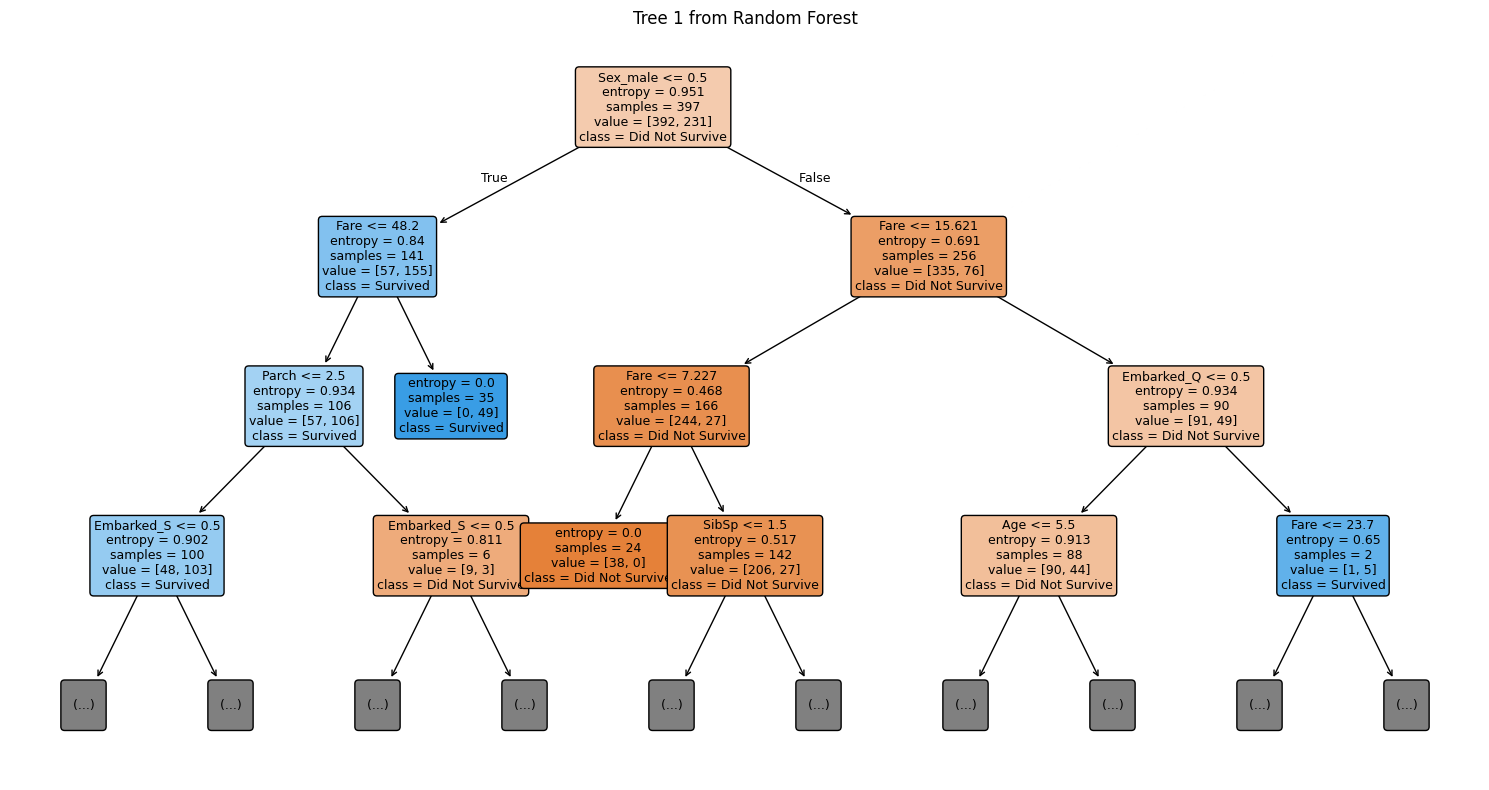

In [70]:
# ============================================================
# 9. VISUALIZE ONE TREE FROM RANDOM FOREST
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title("Tree 1 from Random Forest")
plt.tight_layout()
plt.show()

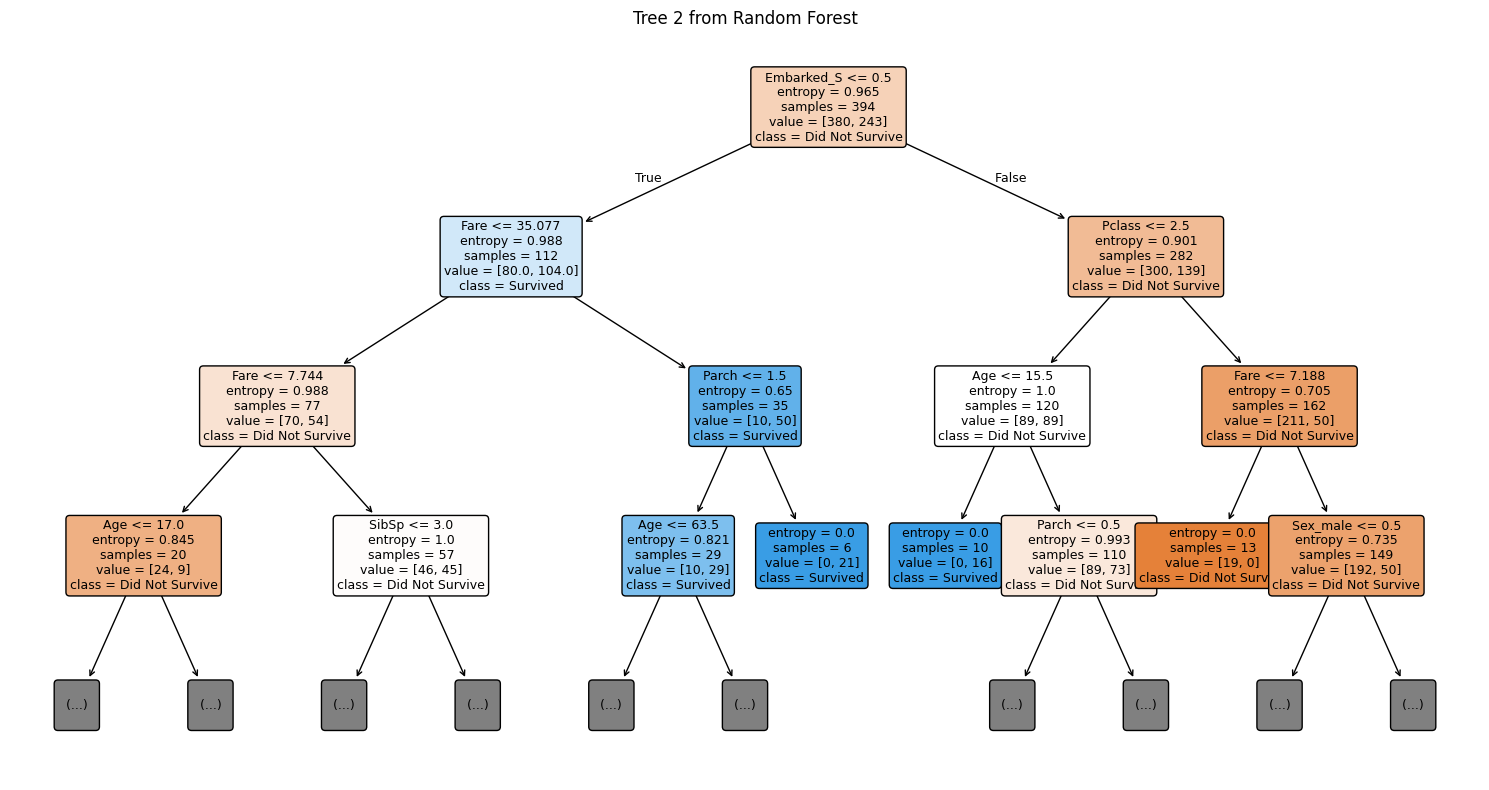

In [71]:
plt.figure(figsize=(15, 8))

plot_tree(
    rf.estimators_[1],
    feature_names=X.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title("Tree 2 from Random Forest")
plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["Did Not Survive", "Survived"],
    zero_division=0
))

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       165
       Survived       0.79      0.68      0.73       103

       accuracy                           0.81       268
      macro avg       0.80      0.78      0.79       268
   weighted avg       0.80      0.81      0.80       268



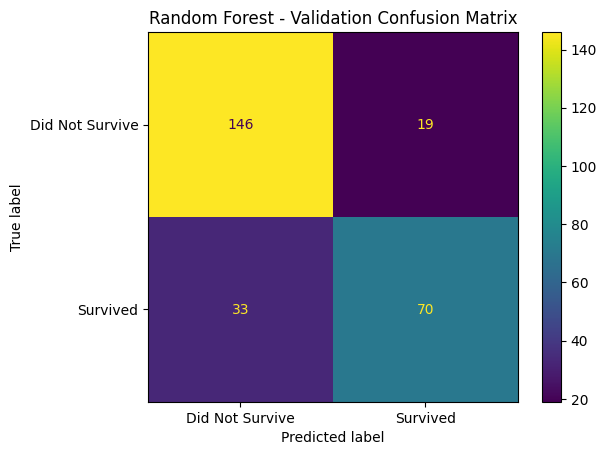

In [56]:
# ============================================================
# 10. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

In [57]:
# ============================================================
# 11. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.6709,0.3291
1,5,0.7769,0.2231
2,10,0.8010,0.1990
3,20,0.8122,0.1878
4,30,0.8138,0.1862
5,50,0.8074,0.1926
6,75,0.8299,0.1701
7,100,0.8218,0.1782
8,150,0.8250,0.1750
9,200,0.8234,0.1766


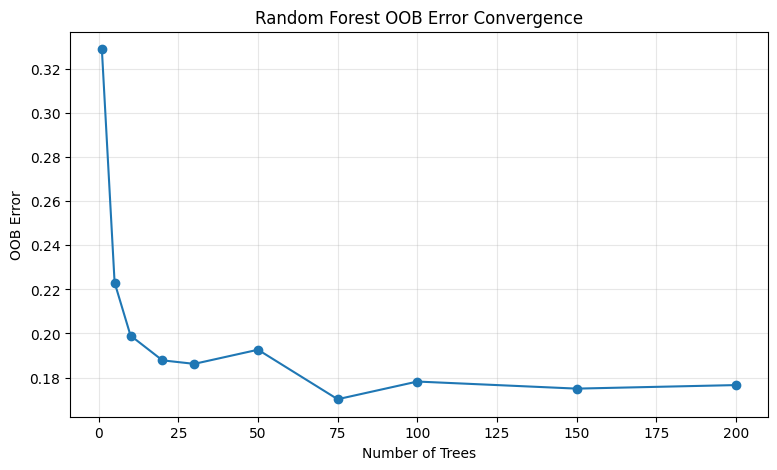

In [58]:
# ============================================================
# 12. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
# ============================================================
# 13. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))


,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,0.9791,0.8060,0.8218,0.1782
1,log2,0.9791,0.8172,0.8250,0.1750
2,None,0.9791,0.8097,0.8186,0.1814


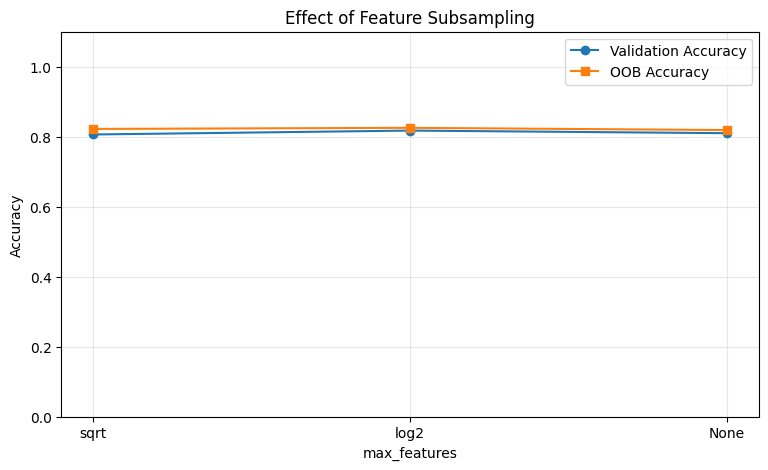

In [60]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


In [61]:
# ============================================================
# 15. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))


Bootstrap indices:
[ 55 482 407 273 269 534  53 434 125  58 327 607 458 474 446 489 319  79
 523 280 311 231 113 577 486 401 250 512 339 276 280 141  57 345 553  39
 534 515 172 393 102 472 436 220  42 604 277 556 422 484 473 121 226 290
 310  27 340  96 463 425 574 463 228 602 255 202 564 230  47 292 495 118
 288  80 427 296 205 141 351 417 585 272 100 518 392 436  60 194 478 518
 271 501 524 241 559 179 149 425 396  87 518 124 501   4 496 490 486 414
 293 439 172 486 346 285 314 354  23  87 152  71 273 416 407 293 532 352
  49 476 357 395 352 344  56 348 495 189 375  19 216 272 612 133 172 254
 618 531  21 145 511  36 533 175 571 182 270 412  78 347 314 488 620 413
 254 253 260 507 200 104 208  14  66  56 480 450 434 287 446 100 561 312
 584  94 309 433 308 277 103 237 148 187 425 392 378 225 597  54 213  73
 211 599 228 566 308 435 284 165 476 603 164 485 162 446 491 279 459 169
  49  60 278 562  79 283 438 126 449 190 503 360 340 110 288 533  12 472
 306 448 413 269 192 390  87 363

In [62]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    # Draw a bootstrap sample from training rows.
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")


50 manually bagged trees trained.


In [63]:
# ============================================================
# 17. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation passengers.
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Majority vote across all trees.
manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)

Manual Bootstrap Bagging Validation Accuracy: 0.8060


In [64]:
# ============================================================
# 18. BAGGING CLASSIFIER
# ============================================================

# Compatible with newer scikit-learn versions.
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")


BAGGING PERFORMANCE
Training Accuracy   : 0.9791
Validation Accuracy : 0.8097


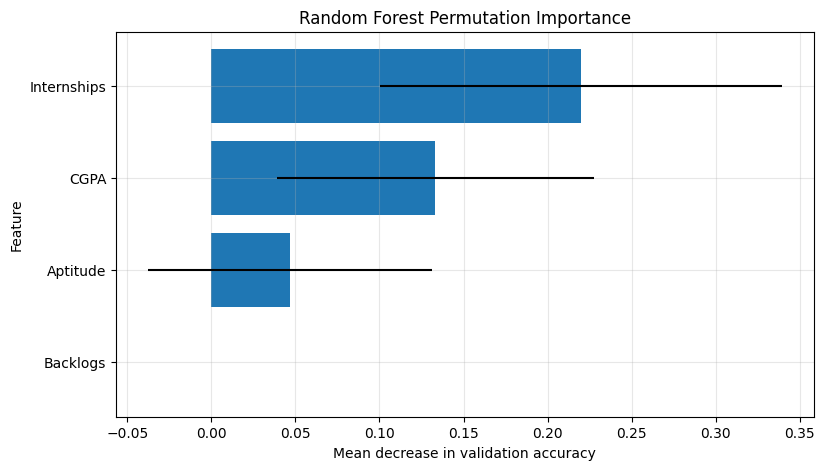

In [65]:
# ============================================================
# 20. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()


In [66]:
# ============================================================
# 21. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    """Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame with columns:
        n_estimators, RF_val_acc, DT_val_acc, OOB_acc

    Also plots three lines:
        1. Random Forest validation accuracy
        2. Single Decision Tree validation accuracy
        3. Random Forest OOB accuracy
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------
    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


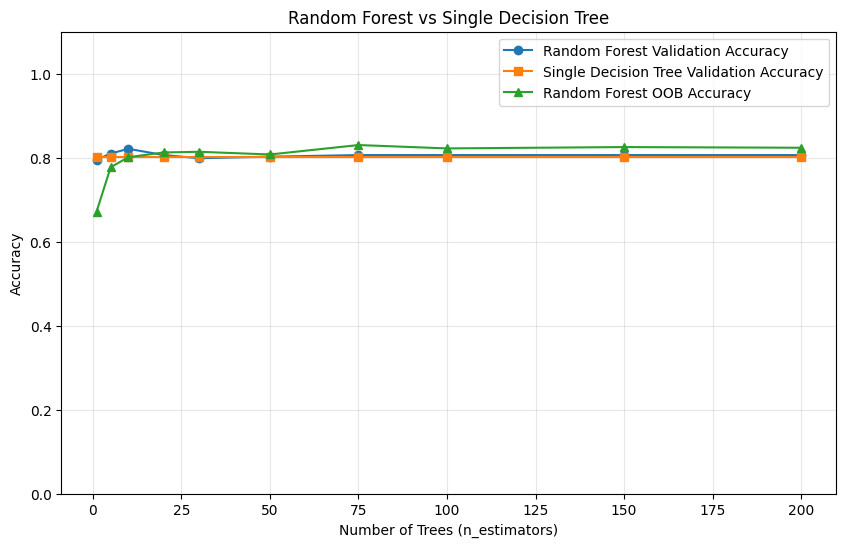

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.7948,0.8022,0.6709
1,5,0.8097,0.8022,0.7769
2,10,0.8209,0.8022,0.8010
3,20,0.8060,0.8022,0.8122
4,30,0.7985,0.8022,0.8138
5,50,0.8022,0.8022,0.8074
6,75,0.8060,0.8022,0.8299
7,100,0.8060,0.8022,0.8218
8,150,0.8060,0.8022,0.8250
9,200,0.8060,0.8022,0.8234


In [67]:
# ============================================================
# 22. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [68]:
# ============================================================
# 23. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())


Best Random Forest result based on validation accuracy:
n_estimators    10.000000
RF_val_acc       0.820896
DT_val_acc       0.802239
OOB_acc          0.800963
